## IMPORTS AND INITIAL SETUP

In [1]:
# Core TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-08-26 07:56:27.336572: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-26 07:56:27.373979: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-26 07:56:27.374019: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-26 07:56:27.375550: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-26 07:56:27.382899: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

In [3]:
# Machine learning utilities
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score
)

In [4]:
# Visualization
import matplotlib.pyplot as plt
plt.style.use("default")

In [6]:
# System and utility imports
import os
import shutil
import datetime
import random

In [9]:
# Install required packages FIRST
print("Installing required packages...")
#!pip install opencv-python-headless --quiet
#!pip install openpyxl --quiet

Installing required packages...


In [8]:
# Now import cv2 after installation
import cv2
print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.12.0


In [10]:
# Experiment tracking imports
from comet_ml import Experiment
from dotenv import load_dotenv

## GPU CONFIGURATION AND VERIFICATION

In [11]:
# List all available devices
print("\n" + "="*50)
print("DEVICE CONFIGURATION")
print("="*50)

devices = tf.config.list_physical_devices()
print("Available devices:", devices)


DEVICE CONFIGURATION
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
# Check for GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")
    
    # Configure GPU memory growth to avoid OOM
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth configured successfully")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("WARNING: No GPU found. Training will use CPU.")

Found 1 GPU(s):
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth configured successfully


In [13]:
# Verify GPU device name
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print(f"WARNING: GPU device not found at expected location. Found: {device_name}")
else:
    print(f"GPU confirmed at: {device_name}")

GPU confirmed at: /device:GPU:0


2025-08-26 08:00:19.755189: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 79196 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:00:05.0, compute capability: 8.0


In [14]:
# Set default device context
tf.device('/device:GPU:0')

print("="*50)
print("SETUP COMPLETE")
print("="*50)

SETUP COMPLETE


2025-08-26 08:00:30.902472: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79196 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:00:05.0, compute capability: 8.0


## COMET ML EXPERIMENT SETUP AND IMAGE DATA LOADING

In [16]:
# Initialize Comet ML experiment for comprehensive tracking
experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),         
    project_name="multi_modal_development",   # Updated project name
    workspace=None,  # Will use default workspace
    auto_histogram_weight_logging=True,         
    auto_histogram_gradient_logging=True,       
    auto_histogram_activation_logging=True,
    auto_log_co2=True,  # Track carbon footprint
    log_code=True,      # Log the code for reproducibility
    log_graph=True      # Log model architecture
)

print(f"Comet experiment initialized: {experiment.get_key()}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorboard, tensorflow, sklearn, keras.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/app' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/anabiosi-data/multi-modal-development/fee554c3d4734183a5358113f360cfda



Comet experiment initialized: fee554c3d4734183a5358113f360cfda


### DATA ARTIFACT RETRIEVAL AND LOCAL SETUP

In [17]:
# Retrieve the dataset artifact from Comet ML
try:
    logged_artifact = experiment.get_artifact("elastography_images_merged")
    print("Successfully retrieved artifact: elastography_images_merged")
    
    # Check if images are already downloaded locally
    local_image_path = "./Elastography_images"
    if not os.path.exists(local_image_path):
        print("Downloading images to local directory...")
        local_artifact = logged_artifact.download("./")
        print(f"Images downloaded to: {os.path.abspath(local_image_path)}")
    else:
        print(f"Images already exist at: {os.path.abspath(local_image_path)}")
        
except Exception as e:
    print(f"Error retrieving artifact: {e}")
    print("Please ensure the artifact 'elastography_images_merged' exists in your Comet project")
    raise

COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' download has been started asynchronously
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB


Successfully retrieved artifact: elastography_images_merged


COMET INFO: Still downloading 1438 file(s), remaining 648.76 MB/722.63 MB, Throughput 4.92 MB/s, ETA ~132s
COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' has been successfully downloaded


Images downloaded to: /app/Elastography_images


### IMAGE DATA LOADING AND PREPROCESSING

In [18]:
# Set reproducibility seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [19]:
# Extract class names from artifact metadata
class_names = logged_artifact.metadata["classes"]
print(f"Class names: {class_names}")

Class names: ['response', 'stable', 'non-response']


In [20]:
# Configure image data generator
IMG_HEIGHT, IMG_WIDTH = 300, 400
BATCH_SIZE_LOAD = 1579  # Load all images at once

dataset_generator = ImageDataGenerator()
dataset = dataset_generator.flow_from_directory(
    local_image_path,
    batch_size=BATCH_SIZE_LOAD,
    class_mode='sparse',              # Integer labels (0, 1, 2)
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=False,                    # Keep original order for alignment
    classes=class_names,              # Explicit class order
    interpolation='bilinear'          # Better quality resizing
)

print(f"Dataset configuration:")
print(f"  - Target size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  - Batch size: {BATCH_SIZE_LOAD}")
print(f"  - Classes: {dataset.class_indices}")
print(f"  - Total samples found: {dataset.samples}")

Found 1578 images belonging to 3 classes.
Dataset configuration:
  - Target size: 300x400
  - Batch size: 1579
  - Classes: {'response': 0, 'stable': 1, 'non-response': 2}
  - Total samples found: 1578


In [21]:
# Load all images and labels into memory
print("\nLoading all images into memory...")
with tf.device('/device:GPU:0'):
    x_images, y_labels = dataset.next()

print(f"Successfully loaded:")
print(f"  - Images shape: {x_images.shape}")
print(f"  - Labels shape: {y_labels.shape}")
print(f"  - Image dtype: {x_images.dtype}")
print(f"  - Label dtype: {y_labels.dtype}")


Loading all images into memory...
Successfully loaded:
  - Images shape: (1578, 300, 400, 3)
  - Labels shape: (1578,)
  - Image dtype: float32
  - Label dtype: float32


In [22]:
# Verify class distribution
label_counts = np.bincount(y_labels.astype(int))
print(f"\nClass distribution:")
for i, (class_name, count) in enumerate(zip(class_names, label_counts)):
    print(f"  - {class_name}: {count} samples ({count/len(y_labels)*100:.1f}%)")


Class distribution:
  - response: 573 samples (36.3%)
  - stable: 492 samples (31.2%)
  - non-response: 513 samples (32.5%)


In [23]:
# Log dataset info to Comet
experiment.log_parameter("dataset_total_samples", len(y_labels))
experiment.log_parameter("image_height", IMG_HEIGHT)
experiment.log_parameter("image_width", IMG_WIDTH)
experiment.log_parameter("num_classes", len(class_names))
for i, (class_name, count) in enumerate(zip(class_names, label_counts)):
    experiment.log_parameter(f"class_{i}_{class_name}_count", count)

## EXCEL DATA LOADING AND ALIGNMENT WITH IMAGES

In [24]:
# Load the Excel file containing elastic modulus data
excel_path = './clustering_all_v5.xlsx'

try:
    df_excel = pd.read_excel(excel_path)
    print(f"Excel file loaded successfully: {excel_path}")
    print(f"Shape: {df_excel.shape}")
    print(f"Columns: {list(df_excel.columns)}")
    
except FileNotFoundError:
    print(f"ERROR: Excel file not found at {excel_path}")
    print("Please ensure the file exists in the current directory")
    raise
except Exception as e:
    print(f"ERROR loading Excel file: {e}")
    raise

# Display first few rows for verification
print(f"\nFirst 5 rows of Excel data:")
print(df_excel.head())

Excel file loaded successfully: ./clustering_all_v5.xlsx
Shape: (1578, 25)
Columns: ['name', 'Respone/stable/non-Response', 'Elastic Modulus SWE (kPa)', 'Perfused Area ', 'Cell lines', 'Type of Cancer', 'Therapy', 'final dimensions  x', 'final dimensions  y', 'final dimensions  z', 'Final Volume', 'initial dimensions  x', 'Initial dimensions  y', 'Initial dimensions  z', 'Initial Volume', 'relative volume', 'stress kPa from comsol ', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']

First 5 rows of Excel data:
                                         name  Respone/stable/non-Response  \
0  4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif                            1   
1  4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif                            1   
2    4T1 LOOK DAY29_1C1_1A_cropped_square.tif                            1   
3  4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif                            1   
4    4T1 LOOK DAY29_1C1

### DATA CLEANING AND PREPARATION

In [26]:
# Extract only the columns we need
required_columns = ['name', 'Elastic Modulus SWE (kPa)']
missing_cols = [col for col in required_columns if col not in df_excel.columns]

if missing_cols:
    print(f"ERROR: Missing required columns: {missing_cols}")
    print(f"Available columns: {list(df_excel.columns)}")
    raise KeyError(f"Required columns not found: {missing_cols}")

df_clean = df_excel[required_columns].copy()

# Rename columns for easier handling
df_clean.rename(columns={
    'name': 'filename',
    'Elastic Modulus SWE (kPa)': 'elastic_modulus_kpa'
}, inplace=True)

# Fix Unicode character issue in filenames (Τ → T)
df_clean['filename'] = df_clean['filename'].str.replace('\u03A4', 'T', regex=False)

# Remove any duplicate filenames
initial_count = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['filename'])
final_count = len(df_clean)

if initial_count != final_count:
    print(f"WARNING: Removed {initial_count - final_count} duplicate filename entries")

print(f"Cleaned Excel data:")
print(f"  - Shape: {df_clean.shape}")
print(f"  - Filename column: {df_clean['filename'].dtype}")
print(f"  - Elastic modulus column: {df_clean['elastic_modulus_kpa'].dtype}")

# Check for missing values
missing_filenames = df_clean['filename'].isnull().sum()
missing_kpa = df_clean['elastic_modulus_kpa'].isnull().sum()

if missing_filenames > 0:
    print(f"WARNING: {missing_filenames} missing filename entries")
if missing_kpa > 0:
    print(f"WARNING: {missing_kpa} missing elastic modulus entries")

print(f"\nElastic modulus statistics:")
print(df_clean['elastic_modulus_kpa'].describe())

Cleaned Excel data:
  - Shape: (1578, 2)
  - Filename column: object
  - Elastic modulus column: float64

Elastic modulus statistics:
count    1578.000000
mean       38.445133
std        12.672226
min        12.500000
25%        27.350000
50%        37.106151
75%        48.408640
max        63.485778
Name: elastic_modulus_kpa, dtype: float64


## IMAGE-EXCEL DATA ALIGNMENT

In [27]:
# Get the filenames from the image dataset
image_filenames = dataset.filenames  # Full paths like 'class/filename.jpg'
image_basenames = [os.path.basename(path) for path in image_filenames]

print(f"Image dataset info:")
print(f"  - Total image files: {len(image_filenames)}")
print(f"  - Sample filenames: {image_basenames[:5]}")

# Create filename lookup dictionary from Excel
excel_filenames_set = set(df_clean['filename'].values)
filename_to_kpa = dict(zip(df_clean['filename'], df_clean['elastic_modulus_kpa']))

print(f"\nExcel data info:")
print(f"  - Unique filenames in Excel: {len(excel_filenames_set)}")
print(f"  - Sample Excel filenames: {list(excel_filenames_set)[:5]}")

Image dataset info:
  - Total image files: 1578
  - Sample filenames: ['4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', '4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', '4T1 LOOK DAY29_1C1_1A_cropped_square.tif', '4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', '4T1 LOOK DAY29_1C1_1D_cropped_square.tif']

Excel data info:
  - Unique filenames in Excel: 1578
  - Sample Excel filenames: ['4T1-BOSENTAN_IMM_-CONTROL_BC1_NONE_b_cropped_square.tif', '4T1-CONTROL_B-CAGE21D_f_cropped_square.tif', 'B6-EPIRU6_MIC_-CAGE82A_cropped_square.tif', 'B6-BOSENTAN_IMM_-BOSE+IMMUC7_1A_b_cropped_square.tif', '4T1-BOSENTAN 0.2-CAGE31A_c_cropped_square.tif']


In [28]:
# Find matches and mismatches
image_basenames_set = set(image_basenames)
matched_files = image_basenames_set.intersection(excel_filenames_set)
missing_in_excel = image_basenames_set - excel_filenames_set
missing_in_images = excel_filenames_set - image_basenames_set

print(f"\nAlignment analysis:")
print(f"  - Files in both image and Excel: {len(matched_files)}")
print(f"  - Files in images but not Excel: {len(missing_in_excel)}")
print(f"  - Files in Excel but not images: {len(missing_in_images)}")

if missing_in_excel:
    print(f"  - Examples missing in Excel: {list(missing_in_excel)[:10]}")
if missing_in_images:
    print(f"  - Examples missing in images: {list(missing_in_images)[:10]}")


Alignment analysis:
  - Files in both image and Excel: 1578
  - Files in images but not Excel: 0
  - Files in Excel but not images: 0


In [29]:
# Create aligned numeric array
print(f"\nCreating aligned numeric features...")
X_numeric = np.array([filename_to_kpa[basename] for basename in image_basenames], 
                     dtype=np.float32).reshape(-1, 1)

print(f"Numeric features created:")
print(f"  - Shape: {X_numeric.shape}")
print(f"  - Data type: {X_numeric.dtype}")
print(f"  - Min value: {X_numeric.min():.3f}")
print(f"  - Max value: {X_numeric.max():.3f}")
print(f"  - Mean value: {X_numeric.mean():.3f}")


Creating aligned numeric features...
Numeric features created:
  - Shape: (1578, 1)
  - Data type: float32
  - Min value: 12.500
  - Max value: 63.486
  - Mean value: 38.445


### DATA INTEGRITY VERIFICATION

In [30]:
# Verify all arrays have same length
assert x_images.shape[0] == X_numeric.shape[0] == y_labels.shape[0], \
    f"Shape mismatch: images={x_images.shape[0]}, numeric={X_numeric.shape[0]}, labels={y_labels.shape[0]}"

print(f"✓ All data arrays properly aligned:")
print(f"  - Images: {x_images.shape}")
print(f"  - Numeric: {X_numeric.shape}")
print(f"  - Labels: {y_labels.shape}")

✓ All data arrays properly aligned:
  - Images: (1578, 300, 400, 3)
  - Numeric: (1578, 1)
  - Labels: (1578,)


In [31]:
# Spot check random samples
print(f"\nRandom sample verification:")
verification_indices = np.random.choice(len(image_basenames), size=5, replace=False)

for idx in verification_indices:
    filename = image_basenames[idx]
    kpa_aligned = X_numeric[idx, 0]
    kpa_excel = filename_to_kpa[filename]
    label = y_labels[idx]
    class_name = class_names[int(label)]
    
    print(f"  Sample {idx:3d}: {filename}")
    print(f"    Label: {label} ({class_name})")
    print(f"    kPa aligned: {kpa_aligned:.4f}")
    print(f"    kPa Excel: {kpa_excel:.4f}")
    print(f"    Match: {np.isclose(kpa_aligned, kpa_excel)}")


Random sample verification:
  Sample 460: E0771_FM_6_0R.tif
    Label: 0.0 (response)
    kPa aligned: 33.5000
    kPa Excel: 33.5000
    Match: True
  Sample 1458: E0771_TRAN_MIC_DAY11C13_1D_b_cropped_square.tif
    Label: 2.0 (non-response)
    kPa aligned: 61.3995
    kPa Excel: 61.3995
    Match: True
  Sample 1428: E0771_17_M2NR.tif
    Label: 2.0 (non-response)
    kPa aligned: 38.5000
    kPa Excel: 38.5000
    Match: True
  Sample 1278: B6-BOSENTAN-10-CAGE91D_cropped_square.tif
    Label: 2.0 (non-response)
    kPa aligned: 49.7829
    kPa Excel: 49.7829
    Match: True
  Sample 116: 4T1-BOSENTAN 5-CAGE81A_cropped_square.tif
    Label: 0.0 (response)
    kPa aligned: 20.5907
    kPa Excel: 20.5907
    Match: True


In [32]:
# Log alignment statistics to Comet
experiment.log_parameter("excel_total_entries", len(df_clean))
experiment.log_parameter("matched_files", len(matched_files))
experiment.log_parameter("missing_in_excel", len(missing_in_excel))
experiment.log_parameter("missing_in_images", len(missing_in_images))
experiment.log_parameter("kpa_min", float(X_numeric.min()))
experiment.log_parameter("kpa_max", float(X_numeric.max()))
experiment.log_parameter("kpa_mean", float(X_numeric.mean()))
experiment.log_parameter("kpa_std", float(X_numeric.std()))

## TRAIN/VALIDATION/TEST SPLIT AND PREPROCESSING

### INITIAL DATA SHUFFLE

In [33]:
print("Shuffling all data with fixed seed for reproducibility...")

# Shuffle all data together to maintain alignment
X_img_all, X_num_all, y_all = shuffle(
    x_images,     # Image array
    X_numeric,    # Numeric kPa array  
    y_labels,     # Class labels
    random_state=SEED
)

print(f"Data shuffled:")
print(f"  - Images: {X_img_all.shape}")
print(f"  - Numeric: {X_num_all.shape}")
print(f"  - Labels: {y_all.shape}")

Shuffling all data with fixed seed for reproducibility...
Data shuffled:
  - Images: (1578, 300, 400, 3)
  - Numeric: (1578, 1)
  - Labels: (1578,)


### STRATIFIED TRAIN/VALIDATION/TEST SPLIT

In [34]:
# Define split proportions
TEST_FRACTION = 0.15      # 15% for final testing
VAL_FRACTION = 0.15       # 15% for validation  
TRAIN_FRACTION = 0.70     # 70% for training

print(f"Target split proportions:")
print(f"  - Train: {TRAIN_FRACTION*100:.0f}%")
print(f"  - Validation: {VAL_FRACTION*100:.0f}%") 
print(f"  - Test: {TEST_FRACTION*100:.0f}%")

# First split: separate test set (15%)
X_img_temp, X_img_test, X_num_temp, X_num_test, y_temp, y_test = train_test_split(
    X_img_all, X_num_all, y_all,
    test_size=TEST_FRACTION,
    random_state=SEED,
    shuffle=True,
    stratify=y_all  # Maintain class distribution
)

# Second split: divide remaining 85% into train (70%) and validation (15%)
# Relative validation fraction = 15% / (100% - 15%) = 0.176
val_relative_fraction = VAL_FRACTION / (1 - TEST_FRACTION)

X_img_train, X_img_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_img_temp, X_num_temp, y_temp,
    test_size=val_relative_fraction,
    random_state=SEED,
    shuffle=True,
    stratify=y_temp  # Maintain class distribution
)

Target split proportions:
  - Train: 70%
  - Validation: 15%
  - Test: 15%


### SPLIT VERIFICATION AND STATISTICS

In [35]:
print(f"\nFinal split sizes:")
print(f"  - Train:      {X_img_train.shape[0]:4d} samples ({X_img_train.shape[0]/len(y_all)*100:.1f}%)")
print(f"  - Validation: {X_img_val.shape[0]:4d} samples ({X_img_val.shape[0]/len(y_all)*100:.1f}%)")
print(f"  - Test:       {X_img_test.shape[0]:4d} samples ({X_img_test.shape[0]/len(y_all)*100:.1f}%)")
print(f"  - Total:      {X_img_train.shape[0] + X_img_val.shape[0] + X_img_test.shape[0]:4d} samples")

# Verify class distribution across splits
def print_class_distribution(labels, split_name):
    class_counts = np.bincount(labels.astype(int), minlength=len(class_names))
    print(f"\n{split_name} class distribution:")
    for i, (name, count) in enumerate(zip(class_names, class_counts)):
        percentage = count / len(labels) * 100
        print(f"  - {name}: {count:3d} samples ({percentage:4.1f}%)")
    return class_counts

train_dist = print_class_distribution(y_train, "Training")
val_dist = print_class_distribution(y_val, "Validation") 
test_dist = print_class_distribution(y_test, "Testing")


Final split sizes:
  - Train:      1104 samples (70.0%)
  - Validation:  237 samples (15.0%)
  - Test:        237 samples (15.0%)
  - Total:      1578 samples

Training class distribution:
  - response: 401 samples (36.3%)
  - stable: 344 samples (31.2%)
  - non-response: 359 samples (32.5%)

Validation class distribution:
  - response:  86 samples (36.3%)
  - stable:  74 samples (31.2%)
  - non-response:  77 samples (32.5%)

Testing class distribution:
  - response:  86 samples (36.3%)
  - stable:  74 samples (31.2%)
  - non-response:  77 samples (32.5%)


### NUMERIC FEATURE STANDARDIZATION

We standardize the numeric features for several important reasons:
1. Scale Differences
Your elastic modulus values are likely in a range like 20-200 kPa, while your image features (after CNN processing) might be in ranges like 0-1 or -2 to +2. Without standardization, the model would be biased toward the larger-scale features.

2. Neural Network Training Stability
Neural networks train much better when all inputs have similar scales. Large differences in input scales can cause:
Gradient instability (exploding/vanishing gradients)
Slower convergence
Poor weight initialization effectiveness
Difficulty for the optimizer to find good solutions

3. Feature Importance Balance
In your multimodal model, you want both the image features and elastic modulus to contribute meaningfully. If elastic modulus values are much larger in magnitude, the model might ignore the image features entirely.

4. Data Leakage Prevention
The critical part is fitting the scaler ONLY on training data. If we used statistics from the entire dataset (including validation/test), we'd be "leaking" information about future data into our training process. This would make our validation/test performance artificially optimistic.

5. Transformer/Attention Mechanisms
These architectures are particularly sensitive to input scales because they use dot-product attention. Large input values can push the softmax function into saturation regions where gradients become very small.
Think of it this way: if one patient has an elastic modulus of 150 kPa and another has 25 kPa, but after CNN processing their image features are both around 0.5, the model will heavily weight the numeric difference and potentially ignore subtle but important image differences.

Standardization puts everything on a level playing field so the model can learn the optimal combination of both modalities.

In [36]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler on training data only (prevent data leakage)
print("Fitting scaler on training data...")
X_num_train_scaled = scaler.fit_transform(X_num_train)

# Transform validation and test sets using training statistics
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

print(f"Standardization statistics (from training data):")
print(f"  - Original mean: {scaler.mean_[0]:.4f}")
print(f"  - Original std:  {scaler.scale_[0]:.4f}")

print(f"\nStandardized statistics:")
print(f"  - Train mean: {X_num_train_scaled.mean():.6f}, std: {X_num_train_scaled.std():.6f}")
print(f"  - Val mean:   {X_num_val_scaled.mean():.6f}, std: {X_num_val_scaled.std():.6f}")
print(f"  - Test mean:  {X_num_test_scaled.mean():.6f}, std: {X_num_test_scaled.std():.6f}")

Fitting scaler on training data...
Standardization statistics (from training data):
  - Original mean: 38.5249
  - Original std:  12.7227

Standardized statistics:
  - Train mean: 0.000000, std: 1.000000
  - Val mean:   0.032920, std: 1.006417
  - Test mean:  -0.074666, std: 0.961129


### FINAL VERIFICATION

In [37]:
# Confirm all shapes match
datasets = {
    'Train': (X_img_train, X_num_train_scaled, y_train),
    'Validation': (X_img_val, X_num_val_scaled, y_val),
    'Test': (X_img_test, X_num_test_scaled, y_test)
}

all_shapes_valid = True
for split_name, (imgs, nums, labels) in datasets.items():
    imgs_count = imgs.shape[0]
    nums_count = nums.shape[0] 
    labels_count = labels.shape[0]
    
    shapes_match = imgs_count == nums_count == labels_count
    all_shapes_valid = all_shapes_valid and shapes_match
    
    status = "✓" if shapes_match else "✗"
    print(f"{status} {split_name:10s}: imgs={imgs_count:4d}, nums={nums_count:4d}, labels={labels_count:4d}")

if not all_shapes_valid:
    raise ValueError("Shape mismatch detected in data splits!")

print(f"\n✓ All data splits properly aligned and verified")

✓ Train     : imgs=1104, nums=1104, labels=1104
✓ Validation: imgs= 237, nums= 237, labels= 237
✓ Test      : imgs= 237, nums= 237, labels= 237

✓ All data splits properly aligned and verified


### LOG SPLIT STATISTICS TO COMET

In [38]:
# Log split sizes
experiment.log_parameter("train_samples", len(y_train))
experiment.log_parameter("val_samples", len(y_val))  
experiment.log_parameter("test_samples", len(y_test))
experiment.log_parameter("train_fraction", len(y_train)/len(y_all))
experiment.log_parameter("val_fraction", len(y_val)/len(y_all))
experiment.log_parameter("test_fraction", len(y_test)/len(y_all))

# Log class distributions
for split_name, dist in [("train", train_dist), ("val", val_dist), ("test", test_dist)]:
    for i, (class_name, count) in enumerate(zip(class_names, dist)):
        experiment.log_parameter(f"{split_name}_{class_name}_count", int(count))

# Log standardization parameters
experiment.log_parameter("scaler_mean", float(scaler.mean_[0]))
experiment.log_parameter("scaler_std", float(scaler.scale_[0]))

## TF.DATA PIPELINE CREATION AND AUGMENTATION

### PIPELINE CONFIGURATION

In [39]:
# Data pipeline parameters
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
PREFETCH_BUFFER = 2

print(f"Pipeline configuration:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Image target size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  - Auto-tuning enabled: {AUTOTUNE}")

Pipeline configuration:
  - Batch size: 32
  - Image target size: 300x400
  - Auto-tuning enabled: -1


### IMAGE PREPROCESSING FUNCTIONS

In [41]:
def preprocess_images(image, numeric, label):
    """
    Simple but effective preprocessing for SWE images:
    - Resize to target dimensions
    - Normalize to [0, 1] 
    - Apply contrast adjustment to reduce overfitting to acquisition settings
    - Clamp values to valid range
    """
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.adjust_contrast(image, 0.5)  # Reduce contrast for better generalization
    image = tf.clip_by_value(image, 0.0, 1.0)
    return (image, numeric), label

### DATA AUGMENTATION STRATEGY

In [42]:
# Conservative augmentation optimized for SWE images
# Use minimal transformations that preserve elasticity information
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),        # Horizontal flips only
    layers.RandomRotation(0.05),           # ±2.9 degrees - very small rotation
    layers.RandomTranslation(0.05, 0.05),  # 5% translation - minimal positioning variation
    layers.RandomContrast(0.05),           # ±5% contrast - subtle gain adjustments
], name="conservative_swe_augmentation")

def apply_augmentation(image, numeric, label):
    """Apply conservative augmentation to images only"""
    augmented_image = data_augmentation(image)
    return augmented_image, numeric, label

print(f"Conservative SWE augmentation pipeline:")
for i, layer in enumerate(data_augmentation.layers):
    print(f"  {i+1}. {layer.name} - minimal transformation")

Conservative SWE augmentation pipeline:
  1. random_flip - minimal transformation
  2. random_rotation - minimal transformation
  3. random_translation - minimal transformation
  4. random_contrast - minimal transformation


### DATASET CREATION FUNCTION

In [43]:
def create_tf_dataset(images, numerics, labels, shuffle=False, augment_data=False):
    """
    Simple and efficient dataset creation following your proven approach
    
    Args:
        images: Image array
        numerics: Numeric feature array  
        labels: Label array
        shuffle: Whether to shuffle the dataset
        augment_data: Whether to apply data augmentation
    
    Returns:
        Configured tf.data.Dataset ready for training
    """
    
    # Create dataset on CPU to avoid GPU memory issues with large arrays
    with tf.device('/CPU:0'):
        dataset = tf.data.Dataset.from_tensor_slices((images, numerics, labels))
    
    # Apply shuffling if requested
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), seed=SEED)
    
    # Apply augmentation if requested (before preprocessing)
    if augment_data:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=AUTOTUNE)
    
    # Apply preprocessing to all samples
    dataset = dataset.map(preprocess_images, num_parallel_calls=AUTOTUNE)
    
    # Batch and prefetch for optimal performance
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

### CREATE TRAIN/VALIDATION/TEST DATASETS

In [44]:
# Create the three datasets using a simple approach
print(f"\nCreating tf.data datasets...")

train_dataset = create_tf_dataset(
    X_img_train, X_num_train_scaled, y_train,
    shuffle=True, augment_data=True
)

val_dataset = create_tf_dataset(
    X_img_val, X_num_val_scaled, y_val,
    shuffle=False, augment_data=False
)

test_dataset = create_tf_dataset(
    X_img_test, X_num_test_scaled, y_test,
    shuffle=False, augment_data=False
)

print(f"Datasets created:")
print(f"  - Training:   {len(y_train)} samples → {len(y_train)//BATCH_SIZE + (1 if len(y_train)%BATCH_SIZE else 0)} batches")
print(f"  - Validation: {len(y_val)} samples → {len(y_val)//BATCH_SIZE + (1 if len(y_val)%BATCH_SIZE else 0)} batches") 
print(f"  - Test:       {len(y_test)} samples → {len(y_test)//BATCH_SIZE + (1 if len(y_test)%BATCH_SIZE else 0)} batches")


Creating tf.data datasets...
Datasets created:
  - Training:   1104 samples → 35 batches
  - Validation: 237 samples → 8 batches
  - Test:       237 samples → 8 batches


### PIPELINE VERIFICATION

In [45]:
# Test the pipeline by taking one batch from each dataset
print("Testing dataset outputs...")

for dataset_name, dataset in [("Training", train_dataset), ("Validation", val_dataset), ("Test", test_dataset)]:
    try:
        # Get one batch
        sample_batch = next(iter(dataset))
        (img_batch, num_batch), label_batch = sample_batch
        
        print(f"\n{dataset_name} dataset:")
        print(f"  - Image batch shape: {img_batch.shape}")
        print(f"  - Numeric batch shape: {num_batch.shape}")
        print(f"  - Label batch shape: {label_batch.shape}")
        print(f"  - Image dtype: {img_batch.dtype}")
        print(f"  - Numeric dtype: {num_batch.dtype}")
        print(f"  - Label dtype: {label_batch.dtype}")
        print(f"  - Image value range: [{img_batch.numpy().min():.3f}, {img_batch.numpy().max():.3f}]")
        print(f"  - Numeric value range: [{num_batch.numpy().min():.3f}, {num_batch.numpy().max():.3f}]")
        
    except Exception as e:
        print(f"ERROR in {dataset_name} dataset: {e}")
        raise

print(f"\n✓ All datasets created successfully and verified")

Testing dataset outputs...


2025-08-26 08:50:37.502634: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 8937845895923141512
2025-08-26 08:50:37.502891: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 8937845895923141512
2025-08-26 08:50:37.503041: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 12619497150916469616
2025-08-26 08:50:37.503213: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 8937845895923141512
2025-08-26 08:50:37.503284: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 12619497150916469616
2025-08-26 08:50:37.503421: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 12619497150916469616
2025-08-26 08:50:37.503558: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv 


Training dataset:
  - Image batch shape: (32, 300, 400, 3)
  - Numeric batch shape: (32, 1)
  - Label batch shape: (32,)
  - Image dtype: <dtype: 'float32'>
  - Numeric dtype: <dtype: 'float32'>
  - Label dtype: <dtype: 'float32'>
  - Image value range: [0.353, 0.985]
  - Numeric value range: [-1.483, 1.831]

Validation dataset:
  - Image batch shape: (32, 300, 400, 3)
  - Numeric batch shape: (32, 1)
  - Label batch shape: (32,)
  - Image dtype: <dtype: 'float32'>
  - Numeric dtype: <dtype: 'float32'>
  - Label dtype: <dtype: 'float32'>
  - Image value range: [0.367, 0.983]
  - Numeric value range: [-1.597, 1.920]

Test dataset:
  - Image batch shape: (32, 300, 400, 3)
  - Numeric batch shape: (32, 1)
  - Label batch shape: (32,)
  - Image dtype: <dtype: 'float32'>
  - Numeric dtype: <dtype: 'float32'>
  - Label dtype: <dtype: 'float32'>
  - Image value range: [0.351, 0.986]
  - Numeric value range: [-1.598, 1.560]

✓ All datasets created successfully and verified


### LOG PIPELINE CONFIGURATION TO COMET

In [46]:
experiment.log_parameter("batch_size", BATCH_SIZE)
experiment.log_parameter("image_preprocessing_contrast", 0.8)
experiment.log_parameter("augmentation_enabled", True)
experiment.log_parameter("augmentation_rotation", 0.08)
experiment.log_parameter("augmentation_translation", 0.08) 
experiment.log_parameter("augmentation_zoom", 0.05)
experiment.log_parameter("augmentation_contrast", 0.1)
experiment.log_parameter("augmentation_brightness", 0.08)
experiment.log_parameter("augmentation_noise_stddev", 0.01)

## COMBINED ATTENTION CNN + TRANSFORMER ARCHITECTURE

### CUSTOM LAYERS AND COMPONENTS

In [47]:
@tf.keras.utils.register_keras_serializable()
class ParametrisedCompatibility(layers.Layer):
    """Custom compatibility layer for attention mechanism"""
    def __init__(self, kernel_regularizer=None, **kwargs):
        super().__init__(**kwargs)
        self.kernel_regularizer = regularizers.get(kernel_regularizer)
        
    def build(self, input_shape):
        C = input_shape[0][-1]  # Feature dimension
        self.u = self.add_weight(
            name='u',
            shape=(C, 1),
            initializer='uniform',
            regularizer=self.kernel_regularizer,
            trainable=True
        )
        super().build(input_shape)
        
    def call(self, inputs):
        local, g = inputs
        g_proj = K.expand_dims(K.expand_dims(g, 1), 1)
        combined = tf.nn.tanh(local + g_proj)
        return K.dot(combined, self.u)
        
    def compute_output_shape(self, input_shape):
        return (input_shape[0][0], input_shape[0][1], input_shape[0][2], 1)
        
    def get_config(self):
        config = super().get_config()
        config.update({
            "kernel_regularizer": regularizers.serialize(self.kernel_regularizer)
        })
        return config

def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout_rate=0.1, name_prefix="transformer"):
    """
    Enhanced transformer encoder block with pre-normalization
    """
    # Multi-head self-attention with pre-normalization
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_norm1")(inputs)
    attn_output = layers.MultiHeadAttention(
        key_dim=head_size, 
        num_heads=num_heads, 
        dropout=dropout_rate,
        name=f"{name_prefix}_mha"
    )(x, x)
    attn_output = layers.Dropout(dropout_rate, name=f"{name_prefix}_dropout1")(attn_output)
    
    # First residual connection
    x = layers.Add(name=f"{name_prefix}_add1")([inputs, attn_output])
    
    # Feed-forward network with pre-normalization
    normed = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_norm2")(x)
    ff_output = layers.Dense(ff_dim, activation='gelu', name=f"{name_prefix}_ff1")(normed)
    ff_output = layers.Dropout(dropout_rate, name=f"{name_prefix}_dropout2")(ff_output)
    ff_output = layers.Dense(inputs.shape[-1], name=f"{name_prefix}_ff2")(ff_output)
    ff_output = layers.Dropout(dropout_rate, name=f"{name_prefix}_dropout3")(ff_output)
    
    # Second residual connection
    return layers.Add(name=f"{name_prefix}_add2")([x, ff_output])

### CNN FEATURE EXTRACTOR WITH ATTENTION

In [48]:
def build_attention_cnn_extractor(input_shape=(300, 400, 3), reg=0.0005, dropout=0.35):
    """
    CNN feature extractor with attention mechanism from original model
    """
    img_input = keras.Input(shape=input_shape, name='image_input')
    
    # Initial feature extraction layers
    x = layers.Conv2D(16, 7, padding='same', kernel_initializer='he_normal')(img_input)
    x = layers.Conv2D(16, 5, padding='same', kernel_initializer='he_normal')(x)
    local12 = layers.Activation('relu')(x)
    
    x = layers.Conv2D(16, 3, padding='same', kernel_initializer='he_normal')(local12)
    local1 = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(local1)
    x = layers.Dropout(dropout)(x)
    
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(x)
    local2 = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(local2)
    x = layers.Dropout(dropout)(x)
    
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(x)
    local3 = layers.Activation('relu')(x)
    
    x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(local3)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout)(x)
    
    # Global feature extraction
    flat = layers.Flatten()(x)
    g = layers.Dense(64, activation='relu')(flat)
    g = layers.Dropout(0.2)(g)
    global_features = layers.Dense(16, activation='relu', name='global_features')(g)
    
    # Attention mechanism helper function
    def create_attention_branch(local_feat, branch_name):
        # Project local features to same dimension as global
        l_proj = layers.Dense(16)(local_feat)
        
        # Compatibility computation
        compatibility = ParametrisedCompatibility(
            kernel_regularizer=regularizers.l2(reg),
            name=f'compatibility_{branch_name}'
        )([l_proj, global_features])
        
        # Attention weights
        flat_compat = layers.Flatten(name=f'flat_{branch_name}')(compatibility)
        attention_weights = layers.Activation('softmax', name=f'attention_{branch_name}')(flat_compat)
        
        # Attended features
        reshaped_local = layers.Reshape((-1, 16), name=f'reshape_{branch_name}')(l_proj)
        attended = layers.Lambda(
            lambda z: K.squeeze(K.batch_dot(K.expand_dims(z[0], 1), z[1]), 1),
            name=f'attended_{branch_name}'
        )([attention_weights, reshaped_local])
        
        return attended
    
    # Apply attention to different scale features
    attended1 = create_attention_branch(local1, 'scale1')
    attended2 = create_attention_branch(local2, 'scale2') 
    attended12 = create_attention_branch(local12, 'scale12')
    
    return keras.Model(
        img_input, 
        [attended1, attended2, attended12, global_features],
        name='attention_cnn_extractor'
    )

### TRANSFORMER FEATURE EXTRACTOR

In [58]:
def build_transformer_extractor(
    input_shape=(300, 400, 3),
    patch_size=25,
    embed_dim=128,
    num_transformer_layers=4,
    num_heads=8,
    ff_dim=256,
    dropout_rate=0.1
):
    """
    Vision Transformer-style feature extractor
    """
    img_input = keras.Input(shape=input_shape, name='transformer_image_input')
    
    # Create patch embeddings
    batch_size = tf.shape(img_input)[0]
    height, width = input_shape[0], input_shape[1]
    
    # Extract patches
    patches = tf.image.extract_patches(
        images=img_input,
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, patch_size, patch_size, 1],
        rates=[1, 1, 1, 1],
        padding='VALID'
    )
    
    # Reshape to (batch, num_patches, patch_dim)
    patch_dim = patch_size * patch_size * 3
    num_patches = (height // patch_size) * (width // patch_size)
    patches = tf.reshape(patches, [batch_size, num_patches, patch_dim])
    
    # Linear projection to embedding dimension
    patch_embeddings = layers.Dense(embed_dim, name='patch_projection')(patches)
    
    # Add positional embeddings
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=embed_dim, name='pos_embedding')
    pos_encoding = pos_embedding(positions)
    pos_encoding = tf.expand_dims(pos_encoding, axis=0)
    
    # Add positional encoding to patches
    x = patch_embeddings + pos_encoding
    
    # Add learnable CLS token using Embedding layer (serializable)
    cls_embedding = layers.Embedding(input_dim=1, output_dim=embed_dim, name="cls_token_embedding")
    cls_input = tf.zeros((batch_size, 1), dtype=tf.int32)  # Always use index 0
    cls_tokens = cls_embedding(cls_input)  # Shape: (batch_size, 1, embed_dim)
    x = layers.Concatenate(axis=1, name="add_cls_token")([cls_tokens, x])
    
    # Transformer encoder blocks
    for i in range(num_transformer_layers):
        x = transformer_encoder_block(
            x,
            head_size=embed_dim // num_heads,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate,
            name_prefix=f"transformer_layer_{i}"
        )
    
    # Extract CLS token representation
    cls_representation = x[:, 0, :]  # CLS token
    
    # Additional processing to match attention CNN output dimension
    transformer_features = layers.Dense(16, activation='relu', name='transformer_global_features')(cls_representation)
    
    return keras.Model(img_input, transformer_features, name='transformer_extractor')

### COMBINED MULTIMODAL ARCHITECTURE

In [59]:
def build_combined_multimodal_model(
    img_shape=(300, 400, 3),
    num_numeric_feats=1,
    num_classes=3,
    # CNN-Attention parameters
    cnn_reg=0.0005,
    cnn_dropout=0.35,
    # Transformer parameters
    patch_size=25,
    embed_dim=128,
    num_transformer_layers=4,
    transformer_heads=8,
    transformer_ff_dim=256,
    transformer_dropout=0.15,
    # Fusion parameters
    fusion_dropout=0.3,
    final_reg=0.001
):
    """
    Combined architecture integrating both attention-based CNN and transformer
    """
    print(f"Building combined model with:")
    print(f"  - CNN attention with {cnn_dropout} dropout")
    print(f"  - Transformer with {num_transformer_layers} layers, {transformer_heads} heads")
    print(f"  - Patch size: {patch_size}, Embed dim: {embed_dim}")
    
    # Input layers
    image_input = keras.Input(shape=img_shape, name='image_input')
    numeric_input = keras.Input(shape=(num_numeric_feats,), name='numeric_input')
    
    # CNN-Attention branch
    cnn_extractor = build_attention_cnn_extractor(
        input_shape=img_shape,
        reg=cnn_reg,
        dropout=cnn_dropout
    )
    cnn_features = cnn_extractor(image_input)  # Returns [attended1, attended2, attended12, global]
    cnn_attended1, cnn_attended2, cnn_attended12, cnn_global = cnn_features
    
    # Combine CNN attention features
    cnn_combined = layers.Concatenate(name='cnn_attention_fusion')([
        cnn_attended1, cnn_attended2, cnn_attended12, cnn_global
    ])
    
    # Transformer branch
    transformer_extractor = build_transformer_extractor(
        input_shape=img_shape,
        patch_size=patch_size,
        embed_dim=embed_dim,
        num_transformer_layers=num_transformer_layers,
        num_heads=transformer_heads,
        ff_dim=transformer_ff_dim,
        dropout_rate=transformer_dropout
    )
    transformer_features = transformer_extractor(image_input)
    
    # Numeric feature processing
    numeric_processed = layers.Dense(64, activation='relu', name='numeric_dense1')(numeric_input)
    numeric_processed = layers.Dropout(0.2, name='numeric_dropout1')(numeric_processed)
    numeric_processed = layers.Dense(16, activation='relu', name='numeric_dense2')(numeric_processed)
    
    # Multi-modal fusion
    # Combine CNN attention, transformer, and numeric features
    fused_features = layers.Concatenate(name='multimodal_fusion')([
        cnn_combined,           # CNN attention features (64 dim)
        transformer_features,   # Transformer features (16 dim)
        numeric_processed       # Numeric features (16 dim)
    ])
    
    # Final classification layers
    x = layers.Dense(128, activation='gelu', 
                     kernel_regularizer=regularizers.l2(final_reg),
                     name='classification_dense1')(fused_features)
    x = layers.Dropout(fusion_dropout, name='classification_dropout1')(x)
    
    x = layers.Dense(64, activation='gelu',
                     kernel_regularizer=regularizers.l2(final_reg),
                     name='classification_dense2')(x)
    x = layers.Dropout(fusion_dropout, name='classification_dropout2')(x)
    
    # Final prediction layer
    predictions = layers.Dense(num_classes, activation='softmax',
                              kernel_regularizer=regularizers.l2(final_reg),
                              name='predictions')(x)
    
    model = keras.Model([image_input, numeric_input], predictions, name='combined_multimodal_model')
    
    return model

### MODEL INSTANTIATION AND COMPILATION

In [60]:
# Create the combined model
combined_model = build_combined_multimodal_model(
    img_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_numeric_feats=1,
    num_classes=len(class_names),
    # Adjust parameters as needed
    patch_size=25,  # Gives 12x16 = 192 patches for 300x400 images
    embed_dim=128,
    num_transformer_layers=4,
    transformer_heads=8
)

# Display model architecture
print(f"\nModel architecture summary:")
combined_model.summary(line_length=100)

# Compile with AdamW optimizer (better for transformers)
initial_lr = 2e-4
optimizer = keras.optimizers.AdamW(
    learning_rate=initial_lr,
    weight_decay=1e-4,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-8
)

combined_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nModel compiled with:")
print(f"  - Optimizer: AdamW (lr={initial_lr})")
print(f"  - Loss: sparse_categorical_crossentropy")
print(f"  - Metrics: accuracy")

# Count total parameters
total_params = combined_model.count_params()
trainable_params = sum([K.count_params(w) for w in combined_model.trainable_weights])

print(f"\nModel complexity:")
print(f"  - Total parameters: {total_params:,}")
print(f"  - Trainable parameters: {trainable_params:,}")

Building combined model with:
  - CNN attention with 0.35 dropout
  - Transformer with 4 layers, 8 heads
  - Patch size: 25, Embed dim: 128

Model architecture summary:
Model: "combined_multimodal_model"
____________________________________________________________________________________________________
 Layer (type)                 Output Shape                  Param #   Connected to                  
 numeric_input (InputLayer)   [(None, 1)]                   0         []                            
                                                                                                    
 image_input (InputLayer)     [(None, 300, 400, 3)]         0         []                            
                                                                                                    
 numeric_dense1 (Dense)       (None, 64)                    128       ['numeric_input[0][0]']       
                                                                                         

### Log model configuration to Comet

In [61]:
experiment.log_parameter("model_type", "combined_attention_transformer")
experiment.log_parameter("cnn_dropout", 0.35)
experiment.log_parameter("transformer_layers", 4)
experiment.log_parameter("transformer_heads", 8)
experiment.log_parameter("patch_size", 25)
experiment.log_parameter("embed_dim", 128)
experiment.log_parameter("total_parameters", total_params)
experiment.log_parameter("initial_learning_rate", initial_lr)

## TRAINING CONFIGURATION AND CALLBACKS

### TRAINING HYPERPARAMETERS

In [62]:
# Training configuration
EPOCHS = 100
INITIAL_LR = 2e-4
MIN_LR = 1e-7
PATIENCE_EARLY_STOP = 20
PATIENCE_LR_REDUCE = 8
LR_REDUCTION_FACTOR = 0.5

print(f"Training configuration:")
print(f"  - Max epochs: {EPOCHS}")
print(f"  - Initial learning rate: {INITIAL_LR}")
print(f"  - Minimum learning rate: {MIN_LR}")
print(f"  - Early stopping patience: {PATIENCE_EARLY_STOP}")
print(f"  - LR reduction patience: {PATIENCE_LR_REDUCE}")

Training configuration:
  - Max epochs: 100
  - Initial learning rate: 0.0002
  - Minimum learning rate: 1e-07
  - Early stopping patience: 20
  - LR reduction patience: 8


### LEARNING RATE SCHEDULING

In [63]:
# Cosine decay with warm restarts for transformer training
cosine_decay = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=INITIAL_LR,
    first_decay_steps=30,  # Restart every 30 epochs
    t_mul=1.0,             # Keep same cycle length
    m_mul=0.8,             # Reduce max LR by 20% each restart
    alpha=0.01             # Minimum LR as fraction of initial
)

# Learning rate scheduler callback
lr_scheduler = keras.callbacks.LearningRateScheduler(
    schedule=lambda epoch, lr: float(cosine_decay(epoch)),
    verbose=1
)

print(f"Learning rate schedule: Cosine decay with restarts")

Learning rate schedule: Cosine decay with restarts


### CALLBACK CONFIGURATION

In [64]:
# Early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_EARLY_STOP,
    restore_best_weights=True,
    start_from_epoch=15,  # Don't stop too early
    verbose=1,
    mode='min'
)

# Reduce learning rate on plateau (backup to cosine schedule)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_REDUCTION_FACTOR,
    patience=PATIENCE_LR_REDUCE,
    min_lr=MIN_LR,
    verbose=1,
    mode='min'
)

# Model checkpointing - save best model
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_combined_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
    mode='max'
)

# Custom callback for detailed metrics logging to Comet
class DetailedCometCallback(keras.callbacks.Callback):
    def __init__(self, experiment, validation_data=None):
        super().__init__()
        self.experiment = experiment
        self.validation_data = validation_data
        self.epoch_count = 0
        
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_count += 1
        logs = logs or {}
        
        # Log basic metrics
        for metric_name, metric_value in logs.items():
            self.experiment.log_metric(metric_name, metric_value, epoch=self.epoch_count)
        
        # Log learning rate
        current_lr = float(self.model.optimizer.learning_rate)
        self.experiment.log_metric('learning_rate', current_lr, epoch=self.epoch_count)
        
        # Every 10 epochs, log more detailed info
        if self.epoch_count % 10 == 0:
            print(f"Epoch {self.epoch_count}: "
                  f"loss={logs.get('loss', 0):.4f}, "
                  f"acc={logs.get('accuracy', 0):.4f}, "
                  f"val_loss={logs.get('val_loss', 0):.4f}, "
                  f"val_acc={logs.get('val_accuracy', 0):.4f}, "
                  f"lr={current_lr:.2e}")

# Instantiate custom callback
comet_callback = DetailedCometCallback(
    experiment=experiment,
    validation_data=val_dataset
)

# Combine all callbacks
callbacks = [
    lr_scheduler,
    early_stopping,
    reduce_lr,
    checkpoint,
    comet_callback
]

print(f"\nConfigured callbacks:")
for i, callback in enumerate(callbacks):
    print(f"  {i+1}. {callback.__class__.__name__}")


Configured callbacks:
  1. LearningRateScheduler
  2. EarlyStopping
  3. ReduceLROnPlateau
  4. ModelCheckpoint
  5. DetailedCometCallback


### TRAINING PREPARATION

In [65]:
# Calculate steps per epoch for progress tracking
train_steps_per_epoch = len(y_train) // BATCH_SIZE
val_steps_per_epoch = len(y_val) // BATCH_SIZE

print(f"\nTraining setup:")
print(f"  - Train steps per epoch: {train_steps_per_epoch}")
print(f"  - Validation steps per epoch: {val_steps_per_epoch}")
print(f"  - Total training samples: {len(y_train)}")
print(f"  - Total validation samples: {len(y_val)}")

# Log training configuration to Comet
experiment.log_parameter("max_epochs", EPOCHS)
experiment.log_parameter("initial_lr", INITIAL_LR)
experiment.log_parameter("min_lr", MIN_LR)
experiment.log_parameter("lr_schedule", "cosine_decay_restarts")
experiment.log_parameter("early_stopping_patience", PATIENCE_EARLY_STOP)
experiment.log_parameter("lr_reduction_patience", PATIENCE_LR_REDUCE)
experiment.log_parameter("batch_size", BATCH_SIZE)
experiment.log_parameter("train_steps_per_epoch", train_steps_per_epoch)
experiment.log_parameter("val_steps_per_epoch", val_steps_per_epoch)


Training setup:
  - Train steps per epoch: 34
  - Validation steps per epoch: 7
  - Total training samples: 1104
  - Total validation samples: 237


### MODEL TRAINING EXECUTION

In [66]:
# Verify datasets before training
print("Pre-training verification:")
try:
    # Test one batch from each dataset
    train_batch = next(iter(train_dataset))
    val_batch = next(iter(val_dataset))
    
    # Test model forward pass
    test_pred = combined_model(train_batch[0])
    print(f"  - Train batch shapes: {[x.shape for x in train_batch[0]]}")
    print(f"  - Model output shape: {test_pred.shape}")
    print("  - All systems ready for training")
    
except Exception as e:
    print(f"ERROR during pre-training verification: {e}")
    raise

print(f"\nTraining with GPU acceleration...")

# Execute training on GPU
with tf.device('/device:GPU:0'):
    print(f"Starting training for {EPOCHS} epochs...")
    
    history = combined_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,  # Progress bars for each epoch
        workers=4,  # Parallel data loading
        use_multiprocessing=False,  # Keep False to avoid issues
        max_queue_size=16  # Larger queue for better throughput
    )

print(f"\n" + "="*50)
print("TRAINING COMPLETED")
print("="*50)

# Training summary
final_epoch = len(history.history['loss'])
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
final_train_acc = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]

print(f"Training summary:")
print(f"  - Completed epochs: {final_epoch}")
print(f"  - Best validation accuracy: {best_val_acc:.4f}")
print(f"  - Best validation loss: {best_val_loss:.4f}")
print(f"  - Final training accuracy: {final_train_acc:.4f}")
print(f"  - Final training loss: {final_train_loss:.4f}")

# Log final results to Comet
experiment.log_parameter("completed_epochs", final_epoch)
experiment.log_parameter("best_val_accuracy", best_val_acc)
experiment.log_parameter("best_val_loss", best_val_loss)
experiment.log_parameter("final_train_accuracy", final_train_acc)
experiment.log_parameter("final_train_loss", final_train_loss)

# Save training history
history_dict = history.history
np.save('combined_model_history.npy', history_dict)
print(f"  - Training history saved to: combined_model_history.npy")

Pre-training verification:
  - Train batch shapes: [TensorShape([32, 300, 400, 3]), TensorShape([32, 1])]
  - Model output shape: (32, 3)
  - All systems ready for training

Training with GPU acceleration...
Starting training for 100 epochs...

Epoch 1: LearningRateScheduler setting learning rate to 0.00019999999494757503.
Epoch 1/100


2025-08-26 09:20:10.161644: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incombined_multimodal_model/attention_cnn_extractor/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/35 [============================>.] - ETA: 0s - loss: 3.9738 - accuracy: 0.3189
Epoch 1: val_accuracy improved from -inf to 0.36287, saving model to best_combined_model.keras
35/35 [==============================] - 25s 187ms/step - loss: 3.9367 - accuracy: 0.3179 - val_loss: 1.3181 - val_accuracy: 0.3629 - lr: 2.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.00019945765961892903.
Epoch 2/100
34/35 [============================>.] - ETA: 0s - loss: 1.3216 - accuracy: 0.3676
Epoch 2: val_accuracy improved from 0.36287 to 0.36709, saving model to best_combined_model.keras
35/35 [==============================] - 4s 118ms/step - loss: 1.3206 - accuracy: 0.3678 - val_loss: 1.2832 - val_accuracy: 0.3671 - lr: 1.9946e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.00019783660536631942.
Epoch 3/100
34/35 [============================>.] - ETA: 0s - loss: 1.2804 - accuracy: 0.4118
Epoch 3: val_accuracy improved from 0.36709 to 0.66245, saving model to bes

## MODEL EVALUATION AND ANALYSIS

### LOAD BEST MODEL AND EVALUATE ON TEST SET

In [67]:
# Load the best model saved during training
print("Loading best model...")
try:
    best_model = keras.models.load_model('best_combined_model.keras')
    print("✓ Best model loaded successfully")
except Exception as e:
    print(f"Warning: Could not load saved model ({e})")
    print("Using current model instead...")
    best_model = combined_model

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = best_model.evaluate(test_dataset, verbose=1)

print(f"\nTest Results:")
print(f"  - Test Loss: {test_loss:.4f}")
print(f"  - Test Accuracy: {test_accuracy:.4f}")

Loading best model...
Using current model instead...

Evaluating on test set...
8/8 [==============================] - 0s 27ms/step - loss: 0.4402 - accuracy: 0.8692

Test Results:
  - Test Loss: 0.4402
  - Test Accuracy: 0.8692


### DETAILED PREDICTIONS AND METRICS

In [68]:
print("\nGenerating detailed predictions...")

# Get predictions on test set
test_predictions = best_model.predict(test_dataset, verbose=1)
test_pred_classes = np.argmax(test_predictions, axis=1)

# Extract true labels from test dataset
y_test_true = []
for batch in test_dataset:
    _, labels = batch
    y_test_true.extend(labels.numpy())
y_test_true = np.array(y_test_true, dtype=int)

print(f"Prediction shapes:")
print(f"  - Test predictions: {test_predictions.shape}")
print(f"  - Predicted classes: {test_pred_classes.shape}")
print(f"  - True labels: {y_test_true.shape}")


Generating detailed predictions...
8/8 [==============================] - 1s 26ms/step
Prediction shapes:
  - Test predictions: (237, 3)
  - Predicted classes: (237,)
  - True labels: (237,)


### CONFUSION MATRIX AND CLASSIFICATION REPORT

<Figure size 1000x800 with 0 Axes>

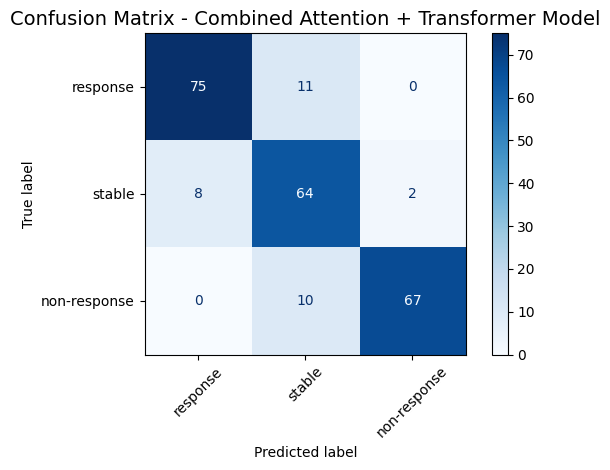


Detailed Classification Report:
              precision    recall  f1-score   support

    response     0.9036    0.8721    0.8876        86
      stable     0.7529    0.8649    0.8050        74
non-response     0.9710    0.8701    0.9178        77

    accuracy                         0.8692       237
   macro avg     0.8759    0.8690    0.8701       237
weighted avg     0.8785    0.8692    0.8716       237


Per-class Performance:
response       : Precision=0.9036, Recall=0.8721, F1=0.8876
stable         : Precision=0.7529, Recall=0.8649, F1=0.8050
non-response   : Precision=0.9710, Recall=0.8701, F1=0.9178


In [69]:
# Confusion Matrix
cm = confusion_matrix(y_test_true, test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Combined Attention + Transformer Model', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix_combined.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Classification Report
print(f"\nDetailed Classification Report:")
print("="*60)
report = classification_report(
    y_test_true, 
    test_pred_classes, 
    target_names=class_names,
    digits=4
)
print(report)

# Per-class metrics
print(f"\nPer-class Performance:")
print("="*40)
for i, class_name in enumerate(class_names):
    class_mask = (y_test_true == i)
    class_pred_mask = (test_pred_classes == i)
    
    true_positives = np.sum((class_mask) & (class_pred_mask))
    false_positives = np.sum((~class_mask) & (class_pred_mask))
    false_negatives = np.sum((class_mask) & (~class_pred_mask))
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{class_name:15s}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

### TRAINING HISTORY VISUALIZATION

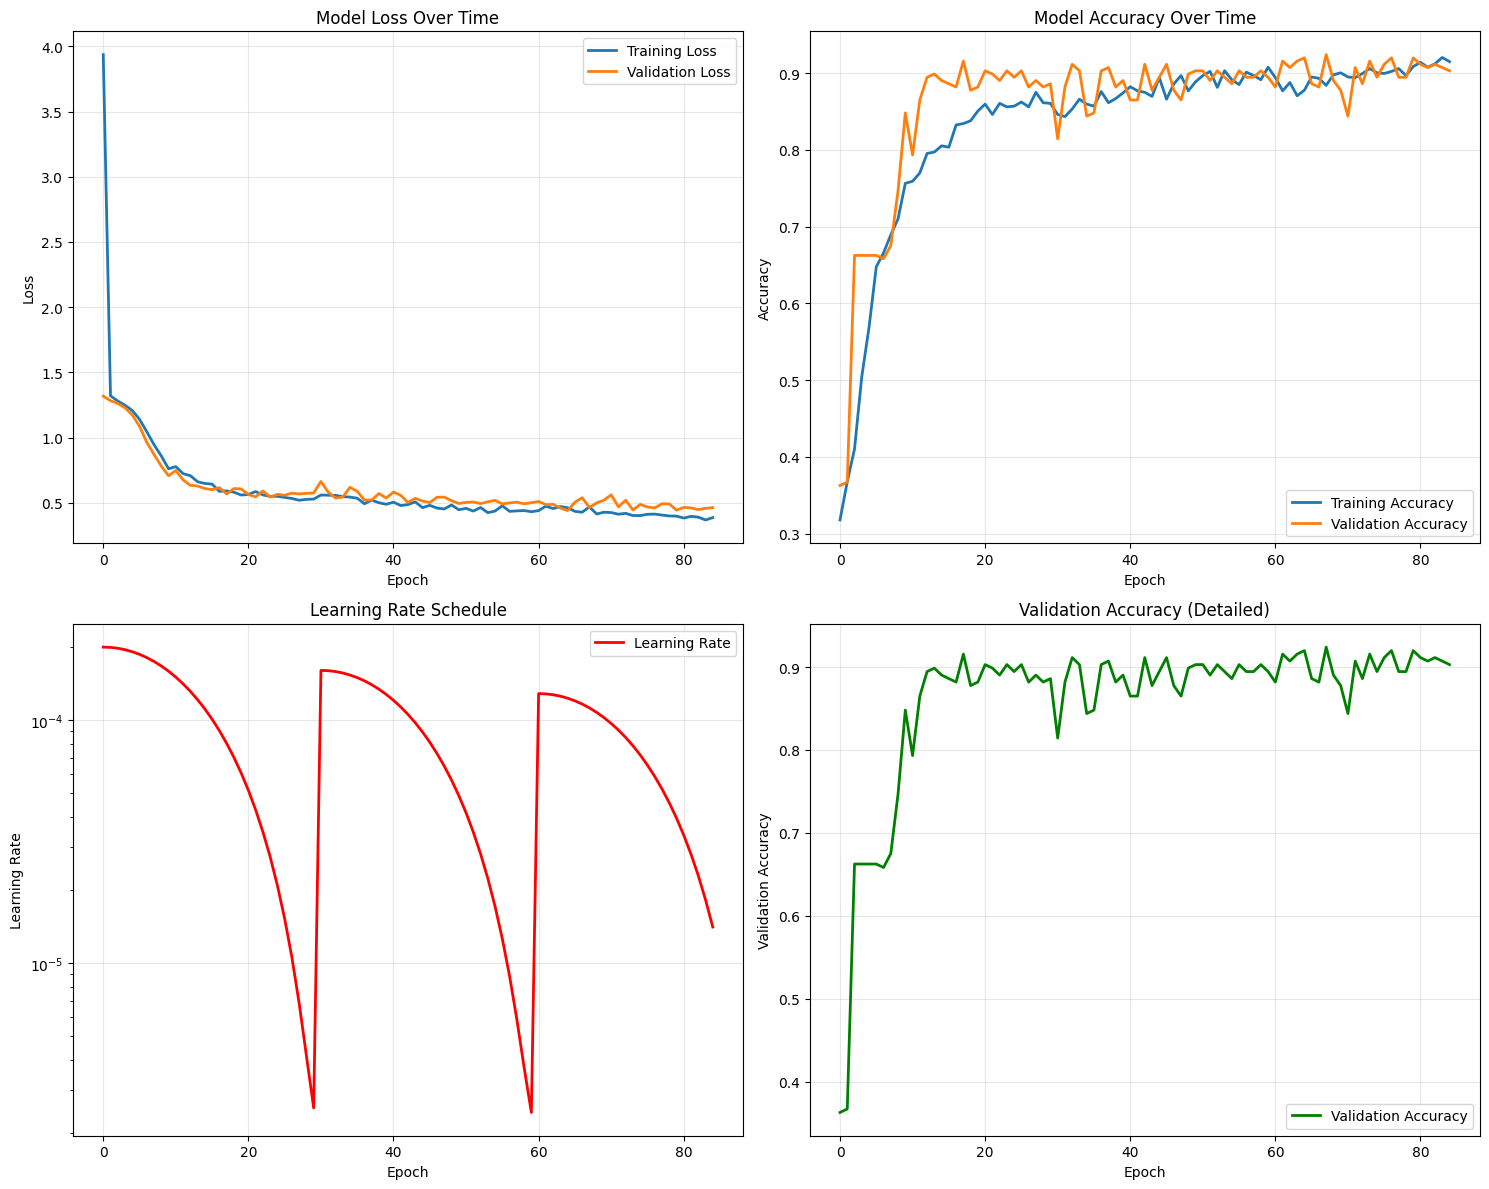

In [70]:
# Load saved history
history_data = np.load('combined_model_history.npy', allow_pickle=True).item()
history_df = pd.DataFrame(history_data)

# Create subplots for training curves
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Loss curves
ax1.plot(history_df.index, history_df['loss'], label='Training Loss', linewidth=2)
ax1.plot(history_df.index, history_df['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Model Loss Over Time')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history_df.index, history_df['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history_df.index, history_df['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Model Accuracy Over Time')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Learning rate curve
if 'lr' in history_df.columns:
    ax3.plot(history_df.index, history_df['lr'], label='Learning Rate', linewidth=2, color='red')
    ax3.set_title('Learning Rate Schedule')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Learning Rate')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Validation accuracy zoomed
ax4.plot(history_df.index, history_df['val_accuracy'], label='Validation Accuracy', linewidth=2, color='green')
ax4.set_title('Validation Accuracy (Detailed)')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Validation Accuracy')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_combined.pdf', bbox_inches='tight', dpi=300)
plt.show()

### SAMPLE PREDICTIONS ANALYSIS

In [72]:
# Show some example predictions
sample_indices = np.random.choice(len(y_test_true), size=20, replace=False)

for idx in sample_indices:
    true_label = y_test_true[idx]
    pred_label = test_pred_classes[idx]
    confidence = test_predictions[idx]
    max_confidence = np.max(confidence)
    
    status = "✓" if true_label == pred_label else "✗"
    
    print(f"{status} Sample {idx:3d}:")
    print(f"    True: {class_names[true_label]:12s} | Pred: {class_names[pred_label]:12s} | Conf: {max_confidence:.3f}")
    print(f"    Probabilities: {' | '.join([f'{class_names[i]}:{confidence[i]:.3f}' for i in range(len(class_names))])}")

✓ Sample  42:
    True: stable       | Pred: stable       | Conf: 0.936
    Probabilities: response:0.015 | stable:0.936 | non-response:0.049
✓ Sample 165:
    True: stable       | Pred: stable       | Conf: 0.506
    Probabilities: response:0.468 | stable:0.506 | non-response:0.027
✓ Sample 179:
    True: response     | Pred: response     | Conf: 0.988
    Probabilities: response:0.988 | stable:0.011 | non-response:0.001
✓ Sample 197:
    True: response     | Pred: response     | Conf: 0.962
    Probabilities: response:0.962 | stable:0.036 | non-response:0.002
✓ Sample 193:
    True: response     | Pred: response     | Conf: 0.942
    Probabilities: response:0.942 | stable:0.054 | non-response:0.003
✓ Sample 204:
    True: non-response | Pred: non-response | Conf: 0.524
    Probabilities: response:0.000 | stable:0.475 | non-response:0.524
✗ Sample  99:
    True: stable       | Pred: response     | Conf: 0.519
    Probabilities: response:0.519 | stable:0.460 | non-response:0.021
✓ Samp

### MODEL PERFORMANCE SUMMARY

In [73]:
# Calculate additional metrics
overall_f1 = f1_score(y_test_true, test_pred_classes, average='weighted')
macro_f1 = f1_score(y_test_true, test_pred_classes, average='macro')

print(f"\n" + "="*50)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*50)

print(f"Dataset Summary:")
print(f"  - Total samples: {len(y_all)}")
print(f"  - Training samples: {len(y_train)} ({len(y_train)/len(y_all)*100:.1f}%)")
print(f"  - Validation samples: {len(y_val)} ({len(y_val)/len(y_all)*100:.1f}%)")
print(f"  - Test samples: {len(y_test)} ({len(y_test)/len(y_all)*100:.1f}%)")

print(f"\nModel Architecture:")
print(f"  - Type: Combined Attention CNN + Transformer")
print(f"  - Total parameters: {best_model.count_params():,}")
print(f"  - Image input: {IMG_HEIGHT}x{IMG_WIDTH}x3")
print(f"  - Numeric features: 1 (elastic modulus)")

print(f"\nFinal Test Performance:")
print(f"  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"  - Test Loss: {test_loss:.4f}")
print(f"  - Weighted F1-Score: {overall_f1:.4f}")
print(f"  - Macro F1-Score: {macro_f1:.4f}")

print(f"\nTraining Summary:")
final_epoch = len(history_data['loss'])
best_val_acc = max(history_data['val_accuracy'])
print(f"  - Epochs completed: {final_epoch}")
print(f"  - Best validation accuracy: {best_val_acc:.4f}")
print(f"  - Final training accuracy: {history_data['accuracy'][-1]:.4f}")

# Log final results to Comet
experiment.log_metric("final_test_accuracy", test_accuracy)
experiment.log_metric("final_test_loss", test_loss)
experiment.log_metric("final_weighted_f1", overall_f1)
experiment.log_metric("final_macro_f1", macro_f1)

# Upload confusion matrix and training curves to Comet
experiment.log_image('confusion_matrix_combined.pdf', name='confusion_matrix')
experiment.log_image('training_curves_combined.pdf', name='training_curves')


FINAL MODEL PERFORMANCE SUMMARY
Dataset Summary:
  - Total samples: 1578
  - Training samples: 1104 (70.0%)
  - Validation samples: 237 (15.0%)
  - Test samples: 237 (15.0%)

Model Architecture:
  - Type: Combined Attention CNN + Transformer
  - Total parameters: 16,059,795
  - Image input: 300x400x3
  - Numeric features: 1 (elastic modulus)

Final Test Performance:
  - Test Accuracy: 0.8692 (86.9%)
  - Test Loss: 0.4402
  - Weighted F1-Score: 0.8716
  - Macro F1-Score: 0.8701

Training Summary:
  - Epochs completed: 85
  - Best validation accuracy: 0.9241
  - Final training accuracy: 0.9149


{'web': 'https://www.comet.com/api/image/download?imageId=ea32566ecbb341a480a0485d384fefbe&experimentKey=fee554c3d4734183a5358113f360cfda',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=ea32566ecbb341a480a0485d384fefbe&experimentKey=fee554c3d4734183a5358113f360cfda',
 'imageId': 'ea32566ecbb341a480a0485d384fefbe'}

### COMPREHENSIVE ERROR ANALYSIS

In [74]:
# 1. VERIFY DATA ALIGNMENT
print("1. Verifying prediction alignment...")
print(f"Total test samples: {len(y_test_true)}")
print(f"Total predictions: {len(test_pred_classes)}")
print(f"Shape match: {len(y_test_true) == len(test_pred_classes)}")

# Calculate actual accuracy manually
correct_predictions = np.sum(y_test_true == test_pred_classes)
manual_accuracy = correct_predictions / len(y_test_true)
print(f"Manual accuracy calculation: {correct_predictions}/{len(y_test_true)} = {manual_accuracy:.4f}")

1. Verifying prediction alignment...
Total test samples: 237
Total predictions: 237
Shape match: True
Manual accuracy calculation: 206/237 = 0.8692


In [75]:
# 2. IDENTIFY ALL ERRORS
print(f"\n2. All misclassified cases:")
error_indices = np.where(y_test_true != test_pred_classes)[0]
print(f"Total errors: {len(error_indices)}")

# Show all errors
for i, idx in enumerate(error_indices):
    true_label = y_test_true[idx]
    pred_label = test_pred_classes[idx]
    confidence = np.max(test_predictions[idx])
    
    print(f"Error {i+1:2d} - Sample {idx:3d}: "
          f"True={class_names[true_label]:12s} → Pred={class_names[pred_label]:12s} "
          f"(conf: {confidence:.3f})")
    
    # Show full probability distribution
    probs = test_predictions[idx]
    prob_str = " | ".join([f"{class_names[j]}:{probs[j]:.3f}" for j in range(len(class_names))])
    print(f"                    Probabilities: {prob_str}")


2. All misclassified cases:
Total errors: 31
Error  1 - Sample   9: True=non-response → Pred=stable       (conf: 0.753)
                    Probabilities: response:0.005 | stable:0.753 | non-response:0.242
Error  2 - Sample  16: True=response     → Pred=stable       (conf: 0.521)
                    Probabilities: response:0.462 | stable:0.521 | non-response:0.016
Error  3 - Sample  29: True=non-response → Pred=stable       (conf: 0.652)
                    Probabilities: response:0.001 | stable:0.652 | non-response:0.346
Error  4 - Sample  34: True=response     → Pred=stable       (conf: 0.828)
                    Probabilities: response:0.134 | stable:0.828 | non-response:0.038
Error  5 - Sample  44: True=non-response → Pred=stable       (conf: 0.622)
                    Probabilities: response:0.001 | stable:0.622 | non-response:0.377
Error  6 - Sample  65: True=response     → Pred=stable       (conf: 0.603)
                    Probabilities: response:0.369 | stable:0.603 | non-res

In [76]:
# 3. ERROR PATTERNS BY CLASS
print(f"\n3. Error patterns by true class:")
for true_class in range(len(class_names)):
    true_class_mask = (y_test_true == true_class)
    true_class_errors = y_test_true[true_class_mask] != test_pred_classes[true_class_mask]
    
    if np.sum(true_class_mask) > 0:
        error_rate = np.mean(true_class_errors)
        total_samples = np.sum(true_class_mask)
        num_errors = np.sum(true_class_errors)
        
        print(f"{class_names[true_class]:12s}: {num_errors:2d}/{total_samples:2d} errors ({error_rate:.1%})")
        
        # Show what this class gets misclassified as
        if num_errors > 0:
            error_preds = test_pred_classes[true_class_mask & (y_test_true != test_pred_classes)]
            for pred_class in range(len(class_names)):
                count = np.sum(error_preds == pred_class)
                if count > 0:
                    print(f"                  → {count} misclassified as {class_names[pred_class]}")


3. Error patterns by true class:
response    : 11/86 errors (12.8%)
                  → 11 misclassified as stable
stable      : 10/74 errors (13.5%)
                  → 8 misclassified as response
                  → 2 misclassified as non-response
non-response: 10/77 errors (13.0%)
                  → 10 misclassified as stable


In [77]:
# 4. CONFIDENCE ANALYSIS
print(f"\n4. Confidence analysis:")
correct_mask = (y_test_true == test_pred_classes)
correct_confidences = np.max(test_predictions[correct_mask], axis=1)
incorrect_confidences = np.max(test_predictions[~correct_mask], axis=1)

print(f"Correct predictions - Mean confidence: {np.mean(correct_confidences):.3f} ± {np.std(correct_confidences):.3f}")
print(f"Incorrect predictions - Mean confidence: {np.mean(incorrect_confidences):.3f} ± {np.std(incorrect_confidences):.3f}")

# Confidence distribution
print(f"\nConfidence distribution for errors:")
for i, conf in enumerate(incorrect_confidences):
    idx = error_indices[i]
    true_label = y_test_true[idx]
    pred_label = test_pred_classes[idx]
    print(f"  {class_names[true_label]:12s} → {class_names[pred_label]:12s}: {conf:.3f}")


4. Confidence analysis:
Correct predictions - Mean confidence: 0.878 ± 0.122
Incorrect predictions - Mean confidence: 0.633 ± 0.109

Confidence distribution for errors:
  non-response → stable      : 0.753
  response     → stable      : 0.521
  non-response → stable      : 0.652
  response     → stable      : 0.828
  non-response → stable      : 0.622
  response     → stable      : 0.603
  non-response → stable      : 0.775
  response     → stable      : 0.500
  non-response → stable      : 0.691
  stable       → response    : 0.504
  response     → stable      : 0.586
  stable       → response    : 0.521
  stable       → response    : 0.519
  response     → stable      : 0.500
  response     → stable      : 0.648
  non-response → stable      : 0.529
  response     → stable      : 0.576
  response     → stable      : 0.501
  non-response → stable      : 0.735
  stable       → non-response: 0.785
  response     → stable      : 0.651
  stable       → response    : 0.514
  response     →

In [78]:
# 5. LOW CONFIDENCE PREDICTIONS (potential uncertain cases)
print(f"\n5. Low confidence predictions (< 0.8):")
low_conf_mask = np.max(test_predictions, axis=1) < 0.8
low_conf_indices = np.where(low_conf_mask)[0]

print(f"Total low confidence predictions: {len(low_conf_indices)}")
for idx in low_conf_indices:
    true_label = y_test_true[idx]
    pred_label = test_pred_classes[idx]
    confidence = np.max(test_predictions[idx])
    status = "✓" if true_label == pred_label else "✗"
    
    print(f"{status} Sample {idx:3d}: True={class_names[true_label]:12s}, "
          f"Pred={class_names[pred_label]:12s}, Conf={confidence:.3f}")


5. Low confidence predictions (< 0.8):
Total low confidence predictions: 80
✓ Sample   5: True=response    , Pred=response    , Conf=0.701
✓ Sample   7: True=stable      , Pred=stable      , Conf=0.633
✓ Sample   8: True=response    , Pred=response    , Conf=0.603
✗ Sample   9: True=non-response, Pred=stable      , Conf=0.753
✓ Sample  13: True=stable      , Pred=stable      , Conf=0.711
✓ Sample  15: True=stable      , Pred=stable      , Conf=0.774
✗ Sample  16: True=response    , Pred=stable      , Conf=0.521
✓ Sample  20: True=response    , Pred=response    , Conf=0.599
✓ Sample  22: True=non-response, Pred=non-response, Conf=0.771
✓ Sample  24: True=response    , Pred=response    , Conf=0.754
✗ Sample  29: True=non-response, Pred=stable      , Conf=0.652
✓ Sample  37: True=stable      , Pred=stable      , Conf=0.694
✓ Sample  38: True=non-response, Pred=non-response, Conf=0.757
✓ Sample  40: True=stable      , Pred=stable      , Conf=0.703
✓ Sample  43: True=non-response, Pred=non

## COMPREHENSIVE MODEL ANALYSIS VISUALIZATIONS

In [80]:
# Install required packages
!pip install umap-learn seaborn --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, precision_recall_curve, average_precision_score
import tensorflow as tf
import os

# Try to import optional packages
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("Seaborn not available, using matplotlib only")

try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
except ImportError:
    HAS_TSNE = False
    print("t-SNE not available due to sklearn version conflict")

# Create output directory
os.makedirs("model_analysis", exist_ok=True)

print("Creating comprehensive model analysis visualizations...")

t-SNE not available due to sklearn version conflict
Creating comprehensive model analysis visualizations...


### GET PREDICTIONS AND TRUE LABELS FROM TEST SET

In [83]:
print("1. Extracting predictions and labels...")

# Get predictions from the model
y_test_prob = best_model.predict(test_dataset, verbose=1)  # Probability scores
y_test_pred = np.argmax(y_test_prob, axis=1)              # Predicted classes

# Extract true labels from test dataset
y_true_list = []
for batch in test_dataset:
    (_, _), labels = batch
    y_true_list.append(labels.numpy())
y_test_true_extracted = np.concatenate(y_true_list).astype(int)

print(f"Predictions shape: {y_test_prob.shape}")
print(f"True labels shape: {y_test_true_extracted.shape}")

1. Extracting predictions and labels...
8/8 [==============================] - 0s 25ms/step
Predictions shape: (237, 3)
True labels shape: (237,)


2. Creating ROC curves...


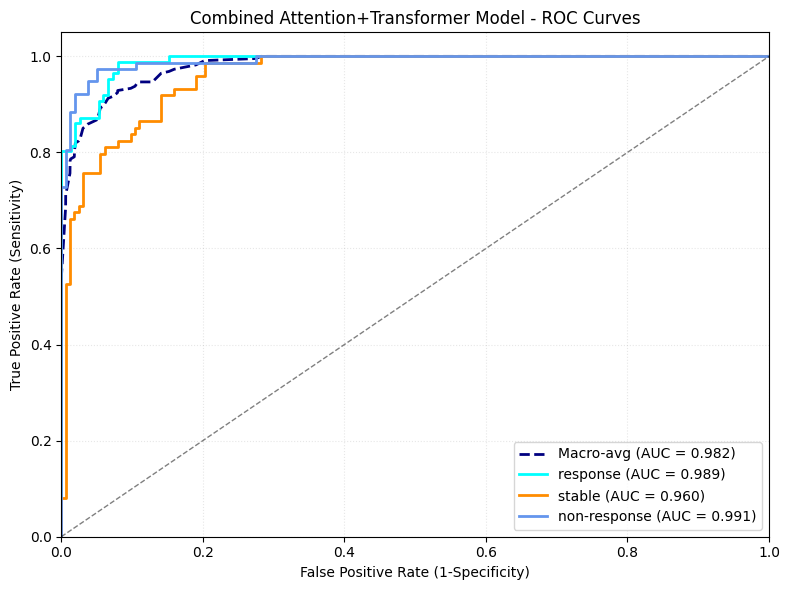

In [84]:
print("2. Creating ROC curves...")

# Binarize labels for multiclass ROC
y_true_bin = label_binarize(y_test_true_extracted, classes=[0, 1, 2])
n_classes = y_true_bin.shape[1]

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)], axis=0)
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-avg (AUC = {roc_auc['macro']:.3f})", 
         lw=2, color='navy', linestyle='--')

colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Combined Attention+Transformer Model - ROC Curves')
plt.legend(loc='lower right')
plt.grid(linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig('model_analysis/roc_curves.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Save ROC data
np.savez("model_analysis/roc_data_combined.npz", fpr=fpr, tpr=tpr, roc_auc=roc_auc)

3. Creating radar chart for per-class metrics...


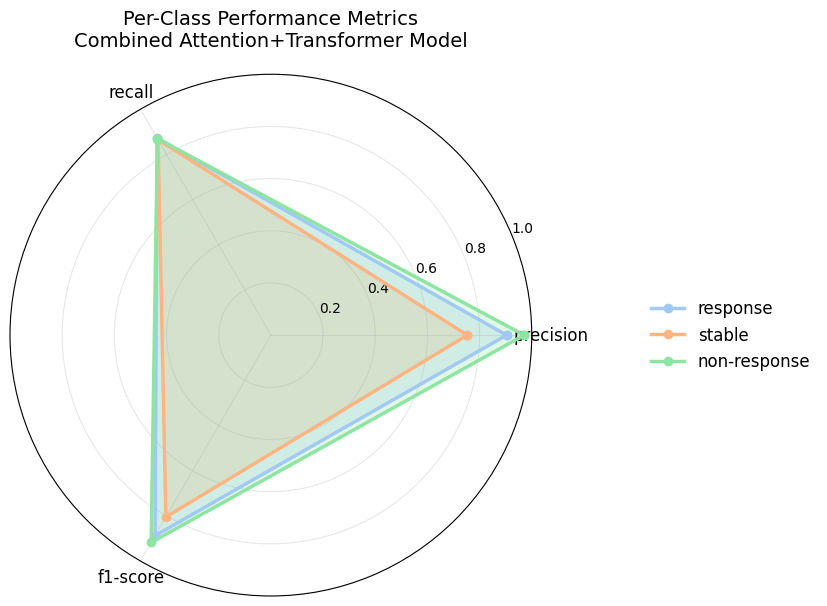

In [85]:
print("3. Creating radar chart for per-class metrics...")

# Get detailed classification report
report = classification_report(
    y_test_true_extracted, y_test_pred,
    target_names=class_names,
    output_dict=True
)

# Create radar chart
metrics = ['precision', 'recall', 'f1-score']
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the circle

colors = ['#a1c9f4', '#ffb482', '#8de5a1']

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))

for i, label in enumerate(class_names):
    values = [report[label][m] for m in metrics]
    values += values[:1]  # Close the polygon
    
    ax.plot(angles, values, color=colors[i], linewidth=2.5, label=label, marker='o')
    ax.fill(angles, values, color=colors[i], alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
ax.grid(True, alpha=0.3)

plt.title('Per-Class Performance Metrics\nCombined Attention+Transformer Model', 
          size=14, pad=20)
plt.legend(loc='center left', bbox_to_anchor=(1.2, 0.5), frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig("model_analysis/radar_metrics.pdf", bbox_inches='tight', dpi=300)
plt.show()

4. Creating precision-recall curves...


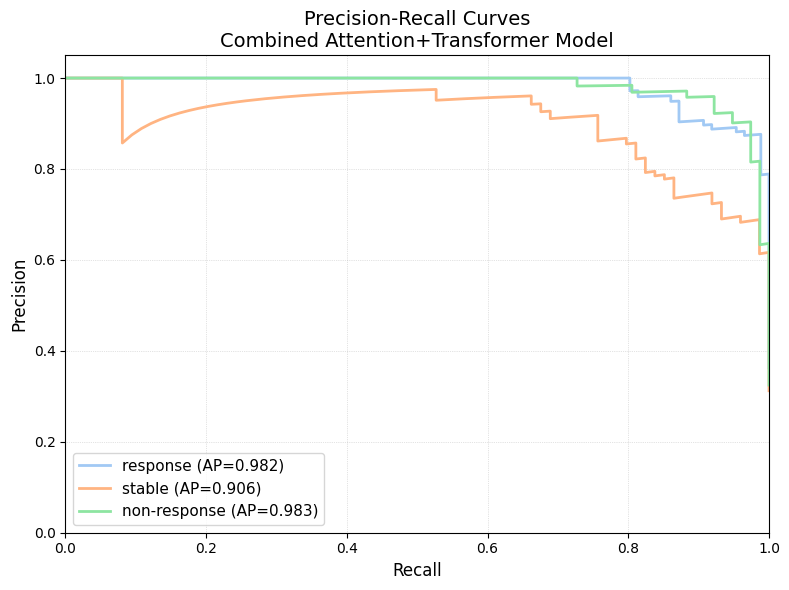

In [86]:
print("4. Creating precision-recall curves...")

plt.figure(figsize=(8, 6))

for i, cname in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_test_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_test_prob[:, i])
    
    plt.plot(recall, precision, label=f"{cname} (AP={ap:.3f})", 
             color=colors[i], linewidth=2)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curves\nCombined Attention+Transformer Model", fontsize=14)
plt.legend(loc='lower left', fontsize=11)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig("model_analysis/precision_recall_curves.pdf", bbox_inches='tight', dpi=300)
plt.show()

6. Creating confidence distribution analysis...


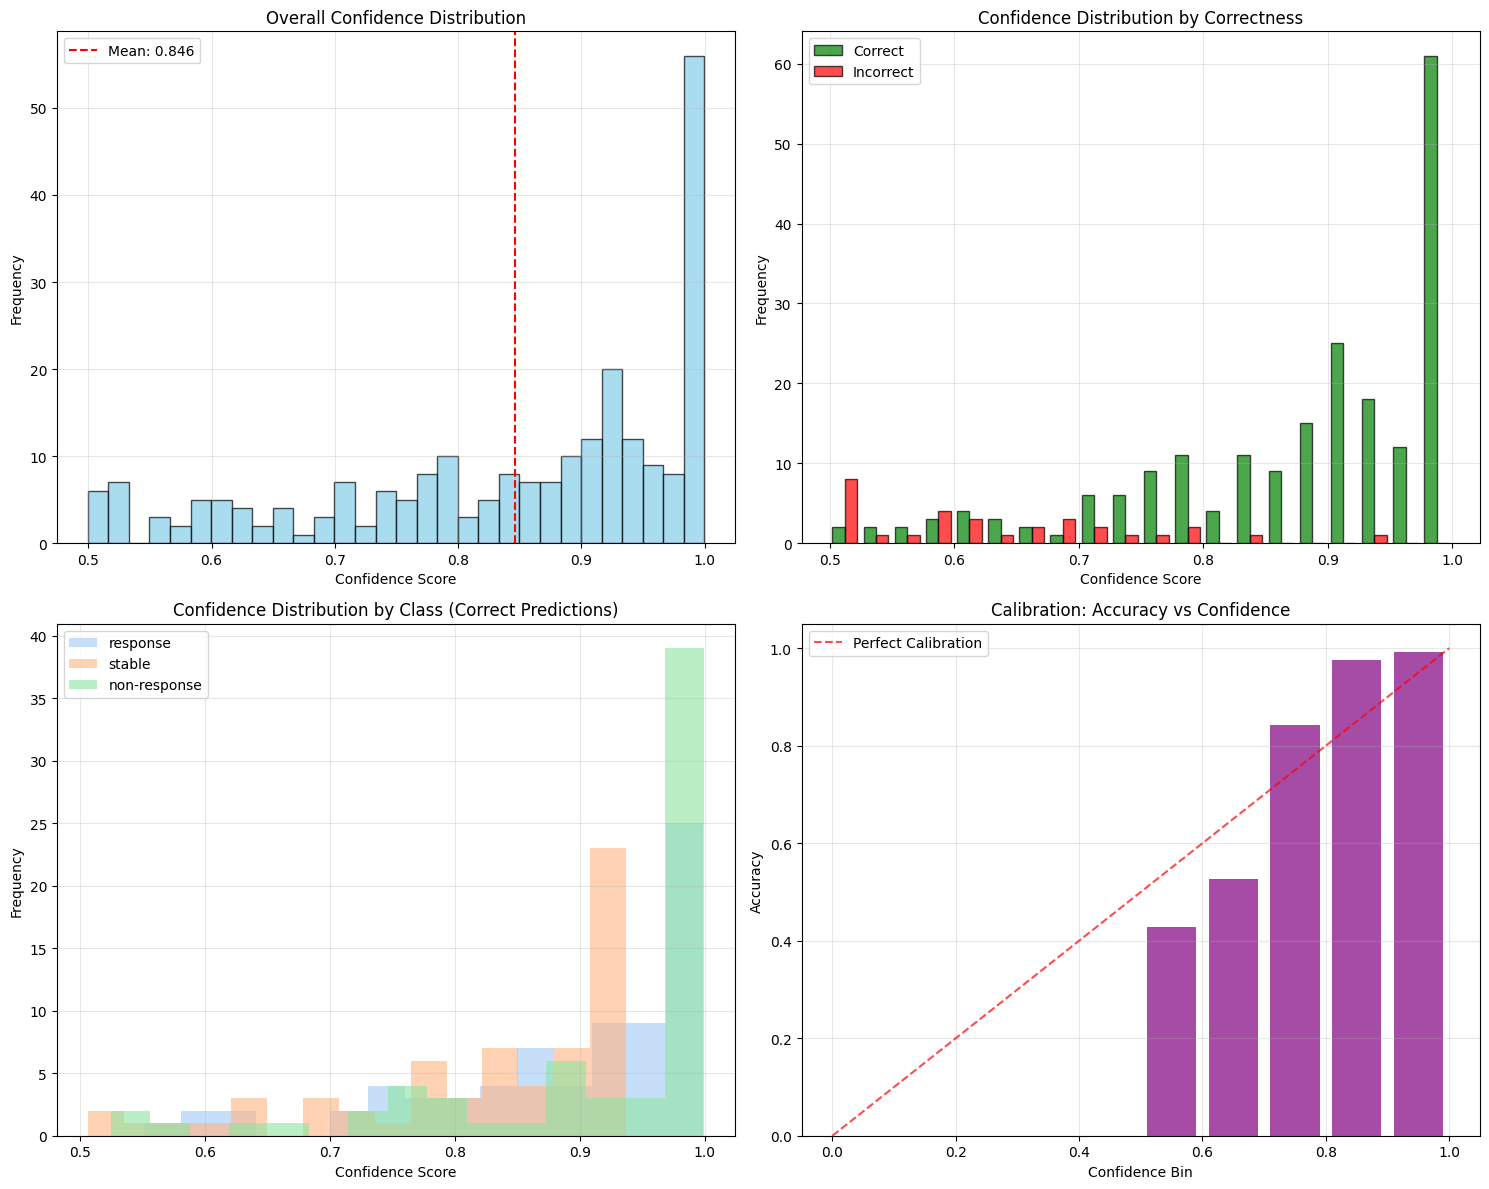

In [88]:
print("6. Creating confidence distribution analysis...")

# Get confidence scores
confidence_scores = np.max(y_test_prob, axis=1)
correct_mask = (y_test_true_extracted == y_test_pred)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Overall confidence distribution
ax1.hist(confidence_scores, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(np.mean(confidence_scores), color='red', linestyle='--', 
           label=f'Mean: {np.mean(confidence_scores):.3f}')
ax1.set_xlabel('Confidence Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Overall Confidence Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Confidence by correctness
ax2.hist([confidence_scores[correct_mask], confidence_scores[~correct_mask]], 
         bins=20, alpha=0.7, label=['Correct', 'Incorrect'], 
         color=['green', 'red'], edgecolor='black')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Confidence Distribution by Correctness')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Confidence by class (correct predictions only)
for i, class_name in enumerate(class_names):
    class_mask = (y_test_true_extracted == i) & correct_mask
    if np.sum(class_mask) > 0:
        ax3.hist(confidence_scores[class_mask], bins=15, alpha=0.6, 
                label=class_name, color=colors[i])

ax3.set_xlabel('Confidence Score')
ax3.set_ylabel('Frequency')
ax3.set_title('Confidence Distribution by Class (Correct Predictions)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Accuracy vs confidence bins
conf_bins = np.linspace(0, 1, 11)
bin_accuracies = []
bin_counts = []

for i in range(len(conf_bins)-1):
    mask = (confidence_scores >= conf_bins[i]) & (confidence_scores < conf_bins[i+1])
    if np.sum(mask) > 0:
        acc = np.mean(correct_mask[mask])
        bin_accuracies.append(acc)
        bin_counts.append(np.sum(mask))
    else:
        bin_accuracies.append(0)
        bin_counts.append(0)

bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2
ax4.bar(bin_centers, bin_accuracies, width=0.08, alpha=0.7, color='purple')
ax4.set_xlabel('Confidence Bin')
ax4.set_ylabel('Accuracy')
ax4.set_title('Calibration: Accuracy vs Confidence')
ax4.plot([0, 1], [0, 1], 'r--', alpha=0.7, label='Perfect Calibration')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model_analysis/confidence_analysis.pdf", bbox_inches='tight', dpi=300)
plt.show()